# House prices prediction using tensorflow decision forests 

Author: Yang Liu

This notebook walks you through how to train a baseline random forest model using decision Forests on the house prices dataset 

Decision forests are a family of tree-based models including Random Forests and Grandient boosted trees. They are the best place to start when working with tabular data, and will often outperform(or provide a strong baseline before you begin experimenting with neural networks)

However, due to conflicts between different packages in my computer and conda environment(the conflicts between the tensorflow and tensorflow_decision_forests), I can't install the 'tensorflow_decision_forests' successfully. Therefore, I used 'ydf' instead. 

The training data and testing data are all downloaded from the kaggle website. 

### Import the library 

In [147]:
import ydf as ydf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [148]:
print('ydf v'+ ydf.__version__)

ydf v0.16.1


### Load the dataset 

In [149]:
train_file_path = './data/train.csv'
dataset_df = pd.read_csv(train_file_path)
print('Full train dataset shape is {}'.format(dataset_df.shape))

Full train dataset shape is (1460, 81)


The data is composed of 81 columns and 1460 entries. We can see all 81 dimensions of our datasets by printing out the first 3 entiries using the following code.   

In [150]:
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


The 'SalePrice' column indicated the house sale price. We will drop the Id column as it's not necessary for model training.  

In [151]:
#dataset_df.drop('Id',axis=1)
#dataset_df.head(3)

In [152]:
#dataset_df.info()

### House price distribution 
Now let's take a look at how the house prices are distributed 

In [153]:
print(dataset_df['SalePrice'].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Figure size 900x800 with 0 Axes>

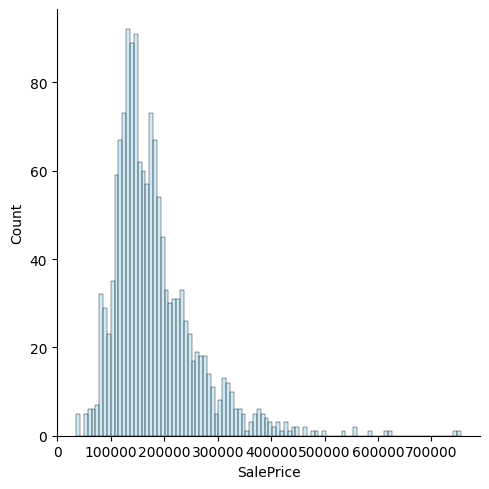

In [154]:
plt.figure(figsize=(9,8))
sns.displot(dataset_df['SalePrice'],color='skyblue',bins=100,alpha=0.4)

### Numerical data distribution 
we will now take a look at how the numerical features are disributed. In order to do this, let's first list all the types of data from our dataset and select only the numerical ones.  

In [155]:
list(set(dataset_df.dtypes.tolist()))

[dtype('O'), dtype('int64'), dtype('float64')]

In [156]:
df_num = dataset_df.select_dtypes(include =['float64', 'int64'] )
df_num.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


In [157]:
corr_matrix = dataset_df.corr(numeric_only = True)

In [158]:
corr_matrix['SalePrice'].sort_values(ascending=False).head(5)

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
Name: SalePrice, dtype: float64

## Prepare the dataset 

In [159]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [160]:
X = dataset_df.drop(['SalePrice'],axis=1)
y = dataset_df['SalePrice']

In [161]:
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.3,
                                                 random_state=42)

In [162]:
train_df = pd.concat ([X_train, y_train], axis=1)

## Train model 

In [163]:
learner = ydf.RandomForestLearner(label='SalePrice',
                                  task=ydf.Task.REGRESSION)
model = learner.train(train_df)

Feature Street is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Feature Utilities is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Feature Condition2 is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Feature PoolQC is a CATEGORICAL feature with an empty dictionary. The feature will not be useful during model training.
Feature MiscFeature is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Train model on 1022 examples
Model trained in 0:00:00.249024


## Evaluate the model(train dataset)

In [164]:
y_train_pred = model.predict(X_train)

In [165]:
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2 = r2_score(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)

In [166]:
print(f'Training dataset RMSE:{rmse:.2f}')
print(f"Training dataset R²: {r2:.4f}")
print(f"Training dataset MAE: {mae:.2f}")

Training dataset RMSE:16937.00
Training dataset R²: 0.9523
Training dataset MAE: 9125.90


RMSE (Root mean square error):
As the house prices ranged from §50 thousand to §500 thousand. 
The RMSE is §16.937 thousand. So the prediction is good. 

MAE (Mean absolute error): 
The MAE is §9.125 thousand. As the house prices ranged from §50 thousand to §500 thousand, the prediction is good.

R²（Coefficient of Determination）
R² = 0.9523（95.23%）
The value is very pretty good. It means that the model can predict 90% changes of house prices. 

> R²> 0.9 → very good

> 0.7～0.9 → good 

> 0.5～0.7 → not bad (medium)

> < 0.5 → not good 

## Evaluate the model(test dataset from train data)

In [181]:
y_pred = model.predict(X_test)

In [182]:
y_test

892     154500
1105    325000
413     115000
522     159000
1036    315500
         ...  
331     139000
323     126175
650     205950
439     110000
798     485000
Name: SalePrice, Length: 438, dtype: int64

In [183]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

In [184]:
print(f'Testing dataset RMSE:{rmse:.2f}')
print(f"Testing dataset: {r2:.4f}")
print(f"Testing dataset: {mae:.2f}")

Testing dataset RMSE:26091.44
Testing dataset: 0.9024
Testing dataset: 15674.22


RMSE (Root mean square error):
As the house prices ranged from §50 thousand to §500 thousand. 
The RMSE is §26.091 thousand. So the prediction is good. 

MAE (Mean absolute error): 
The MAE is §15.674 thousand. As the house prices ranged from §50 thousand to §500 thousand, the prediction is good.

R²（Coefficient of Determination）
R² = 0.9024（90.24%）
The value is very pretty good. It means that the model can predict 90% changes of house prices. 

It's common to see that the R² decreased a bit in the testing dataset compare with the training dataset. 

## Load test data from website 

In [171]:
test_file_path = './data/test.csv'
dataset_test = pd.read_csv(test_file_path)
print('Full train dataset shape is {}'.format(dataset_test.shape))

Full train dataset shape is (1459, 80)


In [172]:
dataset_test.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [173]:
dataset_test.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [175]:
y_dataset_test_pred = model.predict(dataset_test)

In [178]:
ids = dataset_test.pop('Id')

In [179]:
output = pd.DataFrame({'Id': ids,
                       'SalePrice': y_dataset_test_pred})

In [180]:
output.head()

,Id,SalePrice
0,1461,126769.132812
1,1462,151165.671875
2,1463,184476.812500
3,1464,188302.859375
4,1465,203118.953125


In [ ]:
output.to_csv('./data/dataset_test_house_price.csv',index=False)